# ============================================================
# Restaurant Intelligence & Rating Prediction System
#
# Internship Project - Cognifyz Technologies
#
# Author: Adithya B
# Date: June 2026
#
# Objective:
# Analyze restaurant data, discover business insights,
# build predictive models, and create visual dashboards.
# ============================================================

In [2]:
# ============================================================
# Import Libraries
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

In [3]:
df = pd.read_csv("/content/Dataset .csv")

In [4]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [5]:
df.sample(5)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
1273,309387,Instapizza,1,Gurgaon,"SF-008, DLF Galleria, DLF Phase 4, Gurgaon","DLF Galleria, DLF Phase 4","DLF Galleria, DLF Phase 4, Gurgaon",77.082123,28.467504,"Pizza, Fast Food",...,Indian Rupees(Rs.),Yes,Yes,No,No,2,3.6,Yellow,Good,426
3192,60,Colonel's Kababz,1,New Delhi,"29, Defence Colony Market, Defence Colony, New...",Defence Colony,"Defence Colony, New Delhi",77.230591,28.574036,"North Indian, Mughlai",...,Indian Rupees(Rs.),Yes,No,No,No,2,3.2,Orange,Average,600
8499,18312466,Hunger's Hub,1,Noida,"Shop 1, Jalvayu Vihar, Shopping Complex, Secto...",Sector 25,"Sector 25, Noida",77.337865,28.584573,"North Indian, Chinese, Mughlai",...,Indian Rupees(Rs.),No,Yes,No,No,2,3.1,Orange,Average,16
3510,18273617,Punjabi Tandoor,1,New Delhi,"Shop 1/191, Neelkanth Palace, Sant Nagar, East...",East of Kailash,"East of Kailash, New Delhi",77.250705,28.556003,North Indian,...,Indian Rupees(Rs.),No,Yes,No,No,1,0.0,White,Not rated,3
6567,18034082,Just Cakez,1,New Delhi,"2/76, Sir Ganga Ram Road, Old Rajinder Nagar, ...",Rajinder Nagar,"Rajinder Nagar, New Delhi",77.184384,28.636157,Bakery,...,Indian Rupees(Rs.),No,Yes,No,No,2,3.2,Orange,Average,6


In [6]:
print("Rows :", df.shape[0])

Rows : 9551


In [7]:
print("Columns :", df.shape[1])

Columns : 21


The dataset contains 9,551 restaurant records and 21 features describing restaurant characteristics, location information, customer engagement metrics, and ratings.

In [8]:
df.columns.tolist()

['Restaurant ID',
 'Restaurant Name',
 'Country Code',
 'City',
 'Address',
 'Locality',
 'Locality Verbose',
 'Longitude',
 'Latitude',
 'Cuisines',
 'Average Cost for two',
 'Currency',
 'Has Table booking',
 'Has Online delivery',
 'Is delivering now',
 'Switch to order menu',
 'Price range',
 'Aggregate rating',
 'Rating color',
 'Rating text',
 'Votes']

# Phase 1 - Dataset Overview

This section provides a high-level understanding
of the restaurant dataset including:

- Number of observations
- Number of features
- Data types
- Initial inspection

In [9]:
#Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [10]:
#check missing values

In [11]:
missing_df = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": df.isnull().sum()
})

missing_df[missing_df["Missing Values"] > 0]

,Column,Missing Values
Cuisines,Cuisines,9


In [12]:
df["Cuisines"].isnull().sum()

np.int64(9)

Missing values were identified in the Cuisines column. Since cuisine information is categorical and the actual values were unavailable, missing entries were replaced with "Unknown" to preserve records while explicitly indicating unavailable information.

In [13]:
df["Cuisines"] = df["Cuisines"].fillna("Unknown")

In [14]:
df.isnull().sum().sum()

np.int64(0)

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.dtypes

,0
Restaurant ID,int64
Restaurant Name,object
Country Code,int64
City,object
Address,object
Locality,object
Locality Verbose,object
Longitude,float64
Latitude,float64
Cuisines,object


In [18]:
df["Has Table booking"].dtype
df["Has Online delivery"].dtype

dtype('O')

In [19]:
df["Has Table booking"] = df["Has Table booking"].map({
    "Yes":1,
    "No":0
})

df["Has Online delivery"] = df["Has Online delivery"].map({
    "Yes":1,
    "No":0
})

In [20]:
df[["Has Table booking",
    "Has Online delivery"]].head()

,Has Table booking,Has Online delivery
0,1,0
1,1,0
2,1,0
3,0,0
4,1,0


Analyze Target Variable

In [21]:
df["Aggregate rating"].describe()

,Aggregate rating
count,9551.000000
mean,2.666370
std,1.516378
min,0.000000
25%,2.500000
50%,3.200000
75%,3.700000
max,4.900000


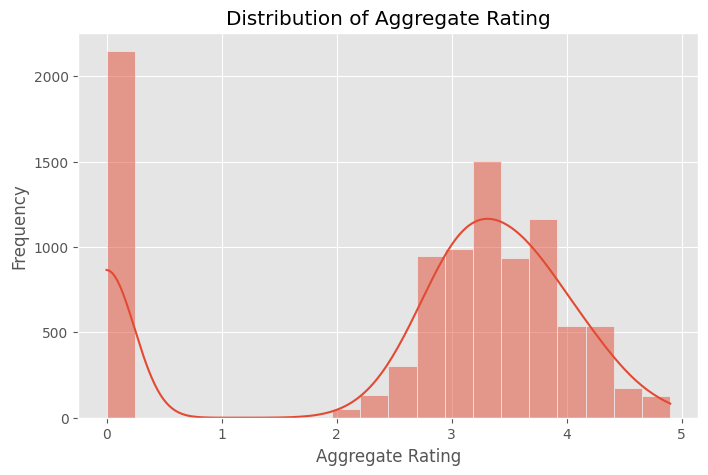

In [22]:
#distribution of aggregate rating
plt.figure(figsize=(8,5))

sns.histplot(
    df["Aggregate rating"],
    bins=20,
    kde=True
)

plt.title("Distribution of Aggregate Rating")
plt.xlabel("Aggregate Rating")
plt.ylabel("Frequency")

plt.show()

Rating Categories

In [23]:
rating_counts = (
    df["Aggregate rating"]
    .value_counts()
    .sort_index()
)

rating_counts

,count
Aggregate rating,
0.0,2148
1.8,1
1.9,2
2.0,7
2.1,15
2.2,27
2.3,47
2.4,87
2.5,110


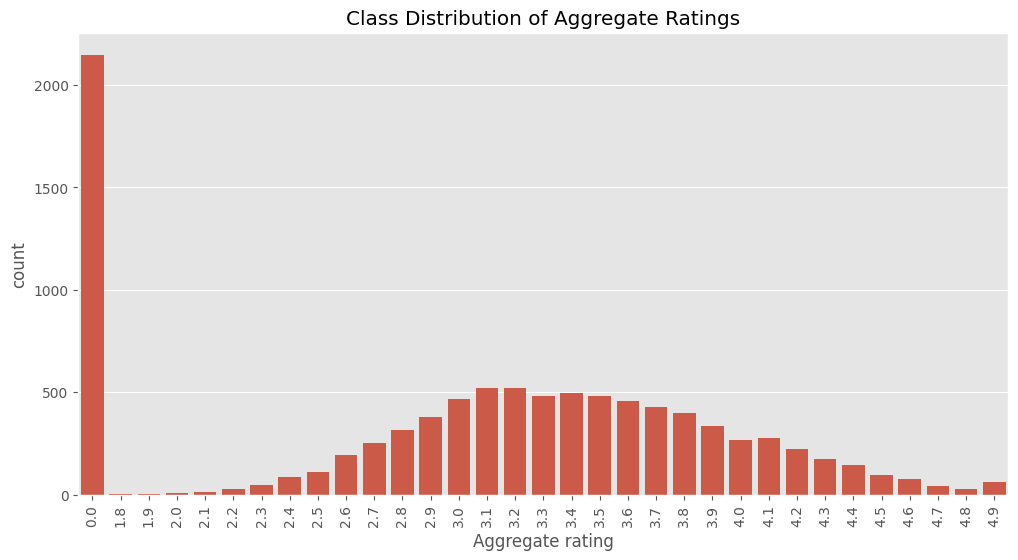

In [24]:
plt.figure(figsize=(12,6))

sns.countplot(
    x="Aggregate rating",
    data=df
)

plt.xticks(rotation=90)

plt.title("Class Distribution of Aggregate Ratings")

plt.show()

In [25]:
df[df["Aggregate rating"] == 0][
    ["Aggregate rating","Rating text"]
].head()

,Aggregate rating,Rating text
30,0.0,Not rated
58,0.0,Not rated
69,0.0,Not rated
77,0.0,Not rated
78,0.0,Not rated


In [26]:
rating_counts = df["Aggregate rating"].value_counts().sort_index()

rating_percent = (
    rating_counts /
    len(df)
) * 100

rating_percent.head()

,count
Aggregate rating,
0.0,22.489792
1.8,0.010470
1.9,0.020940
2.0,0.073291
2.1,0.157052


In [27]:
print(
    f"Percentage of unrated restaurants: "
    f"{(df['Aggregate rating']==0).mean()*100:.2f}%"
)

Percentage of unrated restaurants: 22.49%


The target variable, Aggregate Rating, exhibits a significant class imbalance. Restaurants with a rating of 0.0 account for approximately 22.5% of the dataset and represent unrated establishments. Among rated restaurants, most ratings fall between 2.5 and 4.5, indicating that customer reviews tend to cluster around average to highly rated establishments. This imbalance should be considered during predictive modeling, and unrated restaurants may be excluded from model training to improve prediction accuracy

task2

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9551 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   int64  
 13  Has Online delivery   9551 non-null   int64  
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [29]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Has Table booking,Has Online delivery,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,0.121244,0.256622,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.326428,0.436792,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,0.000000,0.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,0.000000,0.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,0.000000,1.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,1.000000,1.000000,4.000000,4.900000,10934.000000


In [30]:
numerical_cols = df.select_dtypes(include=['int64', 'float64'])

numerical_cols.describe().T

,count,mean,std,min,25%,50%,75%,max
Restaurant ID,9551.0,9.051128e+06,8.791521e+06,53.000000,301962.500000,6.004089e+06,1.835229e+07,1.850065e+07
Country Code,9551.0,1.836562e+01,5.675055e+01,1.000000,1.000000,1.000000e+00,1.000000e+00,2.160000e+02
Longitude,9551.0,6.412657e+01,4.146706e+01,-157.948486,77.081343,7.719196e+01,7.728201e+01,1.748321e+02
Latitude,9551.0,2.585438e+01,1.100794e+01,-41.330428,28.478713,2.857047e+01,2.864276e+01,5.597698e+01
Average Cost for two,9551.0,1.199211e+03,1.612118e+04,0.000000,250.000000,4.000000e+02,7.000000e+02,8.000000e+05
Has Table booking,9551.0,1.212438e-01,3.264275e-01,0.000000,0.000000,0.000000e+00,0.000000e+00,1.000000e+00
Has Online delivery,9551.0,2.566223e-01,4.367920e-01,0.000000,0.000000,0.000000e+00,1.000000e+00,1.000000e+00
Price range,9551.0,1.804837e+00,9.056088e-01,1.000000,1.000000,2.000000e+00,2.000000e+00,4.000000e+00
Aggregate rating,9551.0,2.666370e+00,1.516378e+00,0.000000,2.500000,3.200000e+00,3.700000e+00,4.900000e+00
Votes,9551.0,1.569097e+02,4.301691e+02,0.000000,5.000000,3.100000e+01,1.310000e+02,1.093400e+04


In [31]:
numerical_cols.columns.tolist()

['Restaurant ID',
 'Country Code',
 'Longitude',
 'Latitude',
 'Average Cost for two',
 'Has Table booking',
 'Has Online delivery',
 'Price range',
 'Aggregate rating',
 'Votes']

In [32]:
df["Country Code"].value_counts()

,count
Country Code,
1,8652
216,434
215,80
30,60
189,60
214,60
148,40
208,34
14,24


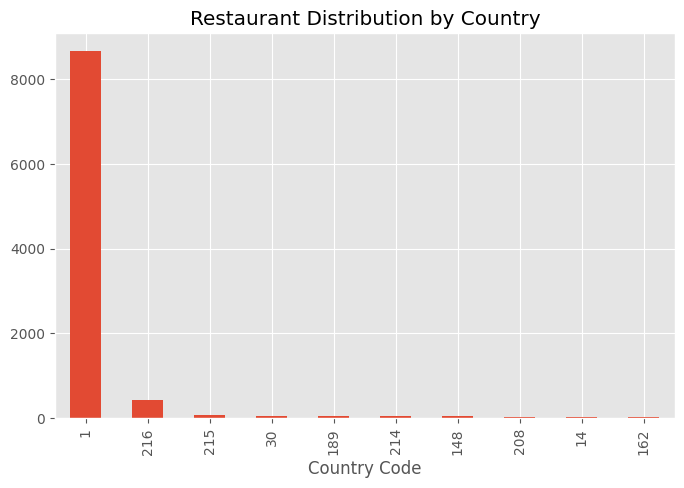

In [33]:
plt.figure(figsize=(8,5))

df["Country Code"].value_counts().head(10).plot(
    kind='bar'
)

plt.title("Restaurant Distribution by Country")
plt.show()

In [34]:
df["Country Code"].value_counts()

,count
Country Code,
1,8652
216,434
215,80
30,60
189,60
214,60
148,40
208,34
14,24


In [35]:
country_mapping = {
    1: 'India',
    216: 'United States',
    215: 'United Kingdom',
    30: 'Brazil',
    189: 'South Africa',
    214: 'United Arab Emirates',
    148: 'New Zealand',
    208: 'Turkey',
    14: 'Australia',
    162: 'Philippines',
    94: 'Indonesia',
    166: 'Qatar',
    184: 'Singapore',
    191: 'Sri Lanka',
    37: 'Canada'
}
df["Country"] = df["Country Code"].map(country_mapping)

In [36]:
df["Country"].isnull().sum()

np.int64(0)

In [37]:
df["Country"].value_counts()

,count
Country,
India,8652
United States,434
United Kingdom,80
Brazil,60
South Africa,60
United Arab Emirates,60
New Zealand,40
Turkey,34
Australia,24


In [38]:
india_percentage = (8652 / 9551) * 100
print(india_percentage)

90.58737304994241


The dataset is highly dominated by restaurants from India, which account for approximately 90.6% of all records. The United States contributes about 4.5% of the restaurants, while the remaining countries each represent only a small fraction of the dataset. Therefore, subsequent analyses and insights are expected to be heavily influenced by restaurant trends in India.

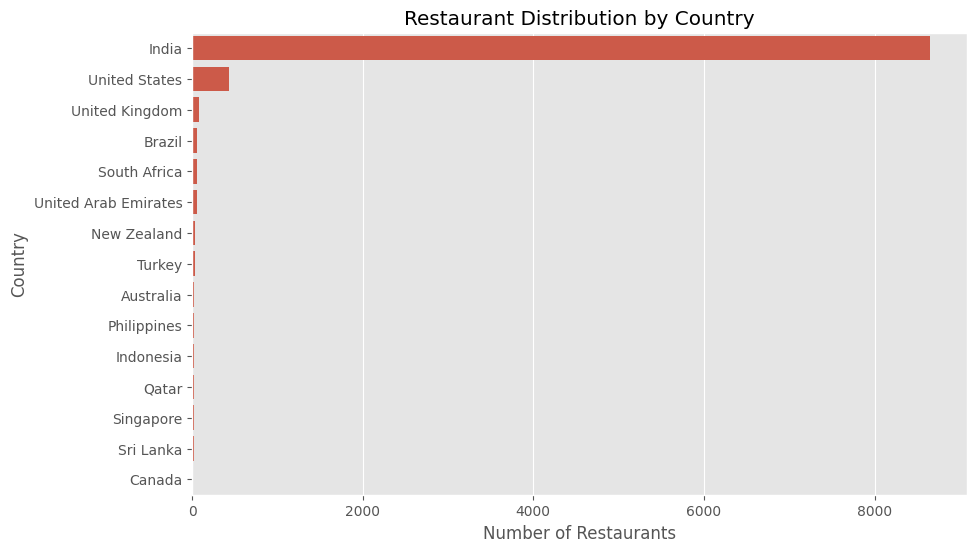

In [39]:
country_counts = df["Country"].value_counts()

plt.figure(figsize=(10,6))

sns.barplot(
    x=country_counts.values,
    y=country_counts.index
)

plt.title("Restaurant Distribution by Country")
plt.xlabel("Number of Restaurants")
plt.ylabel("Country")

plt.show()

In [40]:
top_cities = df["City"].value_counts().head(10)
print(top_cities)

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Lucknow           21
Ahmedabad         21
Amritsar          21
Guwahati          21
Name: count, dtype: int64


In [41]:
all_cuisines = (
    df["Cuisines"]
    .str.split(',')
    .explode()
    .str.strip()
)

print(all_cuisines.value_counts().head(15))

Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Mughlai          995
Italian          764
Bakery           745
Continental      736
Cafe             703
Desserts         653
South Indian     636
Street Food      562
American         390
Pizza            381
Mithai           380
Burger           251
Name: count, dtype: int64


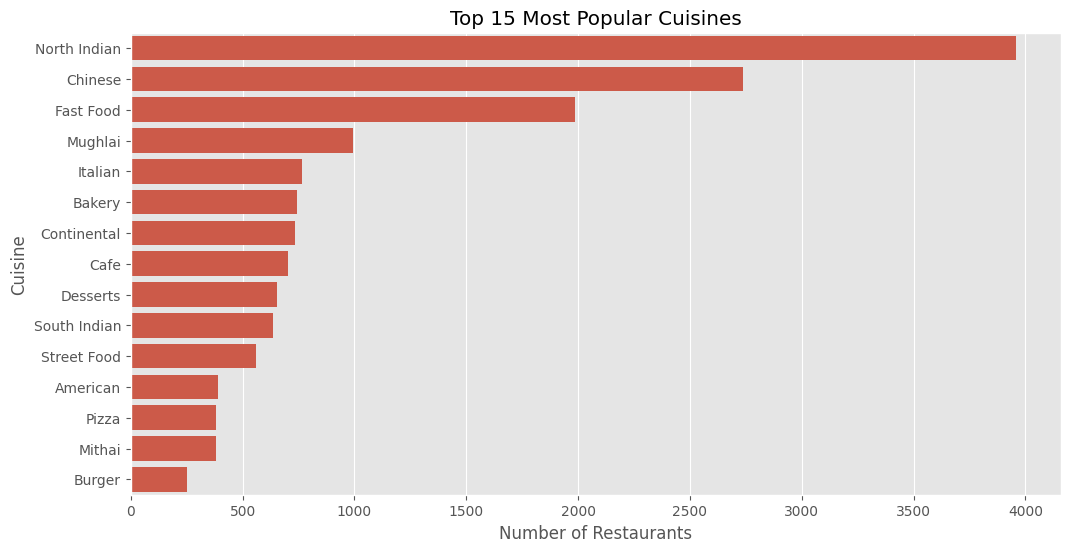

In [42]:
top_cuisines = all_cuisines.value_counts().head(15)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_cuisines.values,
    y=top_cuisines.index
)

plt.title("Top 15 Most Popular Cuisines")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine")

plt.show()

Descriptive analysis revealed that the dataset is highly concentrated in India, particularly within the Delhi-NCR region. New Delhi alone accounts for more than half of all restaurants. Cuisine analysis showed that North Indian cuisine is the most dominant, followed by Chinese and Fast Food. These findings indicate strong regional and cultural influences on restaurant distribution and customer preferences.

In [43]:
#Geospatial Analysis

In [44]:
df[["Latitude", "Longitude"]].describe()

,Latitude,Longitude
count,9551.000000,9551.000000
mean,25.854381,64.126574
std,11.007935,41.467058
min,-41.330428,-157.948486
25%,28.478713,77.081343
50%,28.570469,77.191964
75%,28.642758,77.282006
max,55.976980,174.832089


In [45]:
df[["Latitude", "Longitude"]].isnull().sum()

,0
Latitude,0
Longitude,0


In [46]:
!pip install folium

In [47]:
import folium

In [48]:
restaurant_map = folium.Map(
    location=[
        df["Latitude"].mean(),
        df["Longitude"].mean()
    ],
    zoom_start=2
)

restaurant_map

In [49]:
sample_df = df.sample(
    n=1000,
    random_state=42
)

restaurant_map = folium.Map(
    location=[
        df["Latitude"].mean(),
        df["Longitude"].mean()
    ],
    zoom_start=2
)

for _, row in sample_df.iterrows():

    folium.CircleMarker(
        location=[
            row["Latitude"],
            row["Longitude"]
        ],
        radius=3,
        popup=row["Restaurant Name"],
        fill=True
    ).add_to(restaurant_map)

restaurant_map

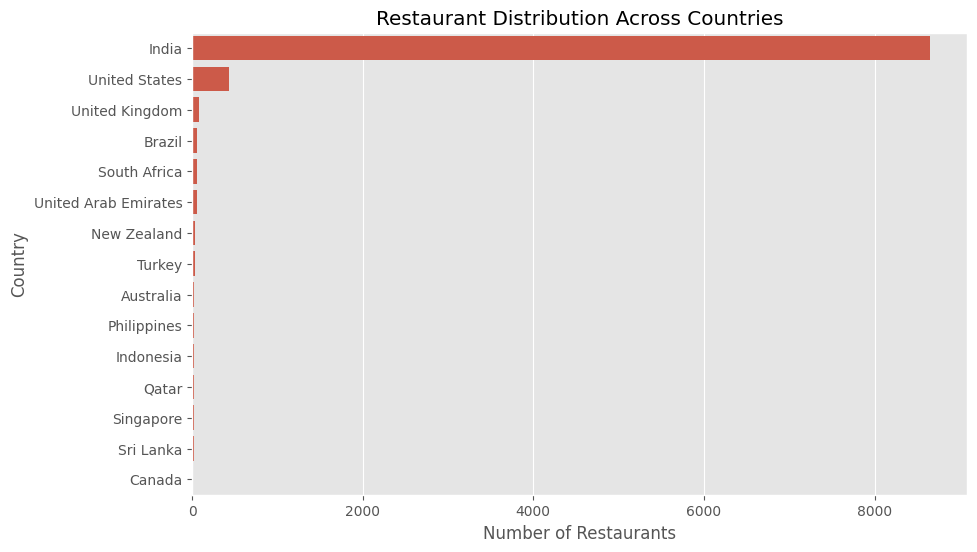

In [50]:
country_counts = df["Country"].value_counts()

plt.figure(figsize=(10,6))

sns.barplot(
    x=country_counts.values,
    y=country_counts.index
)

plt.title("Restaurant Distribution Across Countries")
plt.xlabel("Number of Restaurants")
plt.ylabel("Country")

plt.show()

In [51]:
top_cities = df["City"].value_counts().head(10)

In [52]:
corr_matrix = df[
    ["Latitude",
     "Longitude",
     "Aggregate rating"]
].corr()

corr_matrix

,Latitude,Longitude,Aggregate rating
Latitude,1.000000,0.043207,0.000516
Longitude,0.043207,1.000000,-0.116818
Aggregate rating,0.000516,-0.116818,1.000000


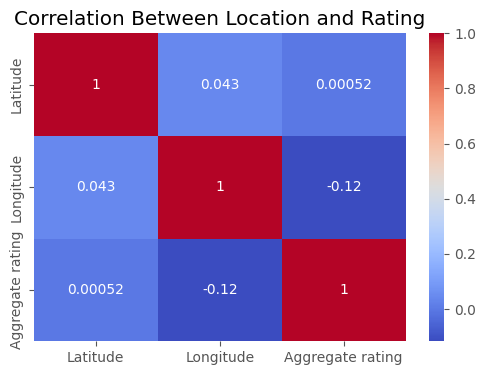

In [53]:
plt.figure(figsize=(6,4))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Correlation Between Location and Rating"
)

plt.show()

Correlation analysis showed that latitude (0.0005) and longitude (-0.1168) have negligible relationships with aggregate ratings. Therefore, geographic coordinates alone do not significantly influence restaurant ratings. Further analysis at the city and country level is recommended to understand regional differences in customer satisfaction and restaurant performance.

In [54]:
country_rating = (
    df.groupby("Country")
    ["Aggregate rating"]
    .mean()
    .sort_values(
        ascending=False
    )
)

country_rating

,Aggregate rating
Country,
Philippines,4.468182
Turkey,4.300000
Indonesia,4.295238
New Zealand,4.262500
United Arab Emirates,4.233333
South Africa,4.210000
United Kingdom,4.087500
Qatar,4.060000
United States,4.004378


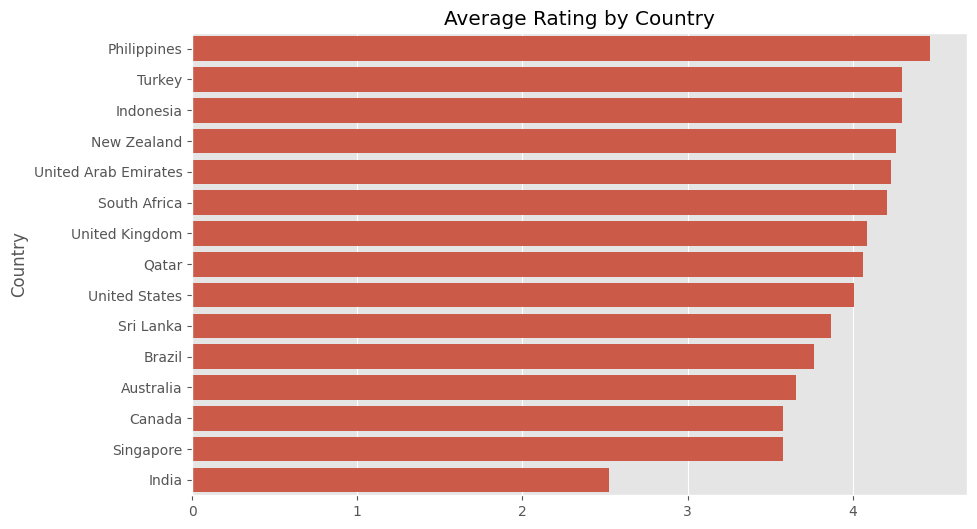

In [55]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=country_rating.values,
    y=country_rating.index
)

plt.title(
    "Average Rating by Country"
)

plt.show()

In [56]:
city_rating = (
    df.groupby("City")
    ["Aggregate rating"]
    .mean()
    .sort_values(
        ascending=False
    )
)

city_rating.head(15)

,Aggregate rating
City,
Inner City,4.900000
Quezon City,4.800000
Makati City,4.650000
Pasig City,4.633333
Mandaluyong City,4.625000
Beechworth,4.600000
London,4.535000
Taguig City,4.525000
Secunderabad,4.500000


Country-level analysis reveals noticeable differences in average restaurant ratings. The Philippines, Turkey, and Indonesia have the highest average ratings, while India has the lowest average rating. However, these results should be interpreted cautiously because the dataset is highly imbalanced, with India contributing over 90% of all observations.

Geospatial analysis showed that latitude and longitude have negligible correlation with restaurant ratings, indicating that geographic coordinates alone do not influence restaurant quality. However, average ratings vary across countries and cities, suggesting that regional factors such as customer preferences, cuisine offerings, and local dining culture may impact restaurant ratings. The dataset is heavily concentrated in India, which should be considered when interpreting location-based insights.

level2

In [57]:
table_booking_pct = (
    df["Has Table booking"].mean()
) * 100

print(f"Table Booking: {table_booking_pct:.2f}%")

Table Booking: 12.12%


Approximately 12.1% of restaurants offer table booking facilities, while the majority do not provide reservation services.

In [58]:
online_delivery_pct = (
    df["Has Online delivery"].mean()
) * 100

print(f"Online Delivery: {online_delivery_pct:.2f}%")

Online Delivery: 25.66%


Around 25.7% of restaurants provide online delivery services, indicating that delivery availability is not universal across the restaurant industry.

In [59]:
table_booking_rating = (
    df.groupby("Has Table booking")
    ["Aggregate rating"]
    .mean()
)

print(table_booking_rating)

Has Table booking
0    2.559359
1    3.441969
Name: Aggregate rating, dtype: float64


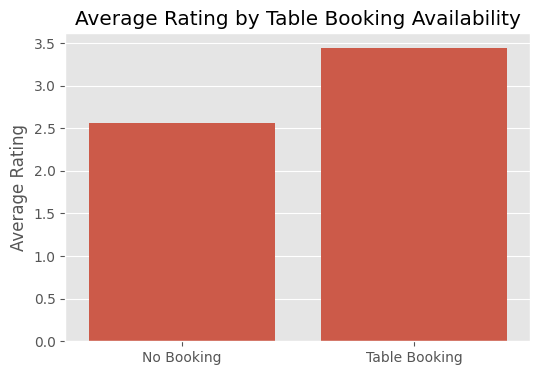

In [60]:
table_booking_rating = (
    df.groupby("Has Table booking")
    ["Aggregate rating"]
    .mean()
)

plt.figure(figsize=(6,4))

sns.barplot(
    x=["No Booking", "Table Booking"],
    y=table_booking_rating.values
)

plt.title("Average Rating by Table Booking Availability")
plt.ylabel("Average Rating")

plt.show()

In [61]:
delivery_price = pd.crosstab(
    df["Price range"],
    df["Has Online delivery"]
)

delivery_price

Has Online delivery,0,1
Price range,,
1,3743,701
2,1827,1286
3,997,411
4,533,53


In [62]:
delivery_price_pct = pd.crosstab(
    df["Price range"],
    df["Has Online delivery"],
    normalize='index'
) * 100

delivery_price_pct

Has Online delivery,0,1
Price range,,
1,84.225923,15.774077
2,58.689367,41.310633
3,70.809659,29.190341
4,90.955631,9.044369


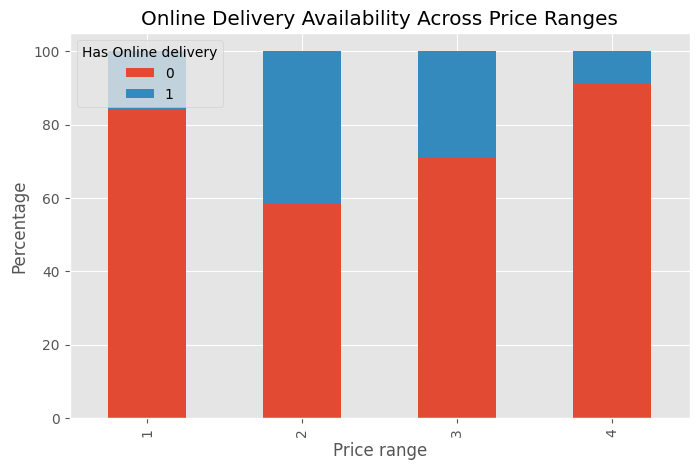

In [63]:
delivery_price_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title(
    "Online Delivery Availability Across Price Ranges"
)

plt.ylabel("Percentage")

plt.show()

Task 2:Price Analysis

In [64]:
price_counts = (
    df["Price range"]
    .value_counts()
    .sort_index()
)

print(price_counts)

Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64


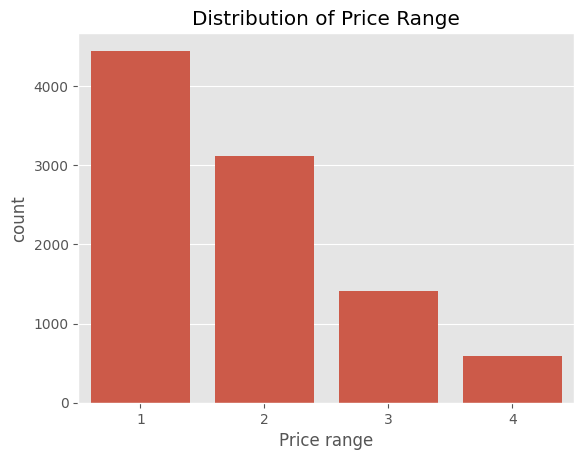

In [65]:
sns.countplot(
    x="Price range",
    data=df
)

plt.title("Distribution of Price Range")
plt.show()


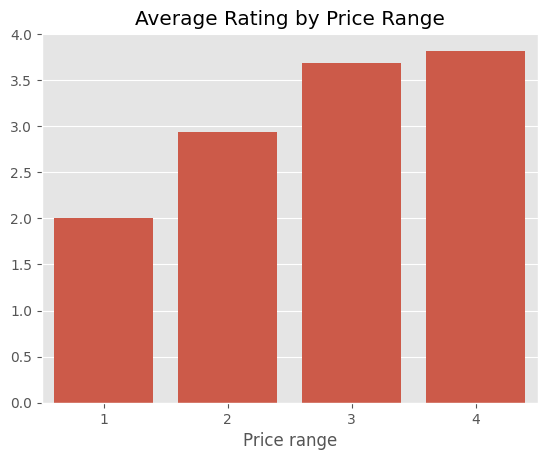

In [67]:
price_rating = (
    df.groupby("Price range")
    ["Aggregate rating"]
    .mean()
)
sns.barplot(
    x=price_rating.index,
    y=price_rating.values
)

plt.title(
    "Average Rating by Price Range"
)

plt.show()

In [68]:
color_rating = (
    df.groupby("Rating color")
    ["Aggregate rating"]
    .mean()
    .sort_values(ascending=False)
)

print(color_rating)

Rating color
Dark Green    4.659801
Green         4.168119
Yellow        3.683429
Orange        3.051619
Red           2.297849
White         0.000000
Name: Aggregate rating, dtype: float64


In [69]:
df.groupby("Price range")["Aggregate rating"].mean()

,Aggregate rating
Price range,
1,1.999887
2,2.941054
3,3.683381
4,3.817918


Price Range 1 is the most common category, accounting for approximately 46.5% of restaurants in the dataset. Analysis of average ratings across price ranges shows that restaurant ratings increase steadily with price level. Furthermore, the Dark Green rating color corresponds to the highest average rating (4.66), indicating excellent customer satisfaction among top-performing restaurants.

In [70]:
df["Restaurant_Name_Length"] = (
    df["Restaurant Name"]
    .str.len()
)

df["Restaurant_Name_Length"].head()

,Restaurant_Name_Length
0,16
1,16
2,22
3,4
4,11


In [83]:
df["Address_Length"] = (
    df["Address"]
    .str.len()
)

df["Address_Length"].head()

,Address_Length
0,71
1,67
2,56
3,70
4,64


In [72]:
df["Cuisine_Count"] = (
    df["Cuisines"]
    .str.split(",")
    .apply(len)
)

In [73]:
df.groupby("Has Table booking")["Aggregate rating"].mean()

,Aggregate rating
Has Table booking,
0,2.559359
1,3.441969


In [74]:
df.groupby("Price range")["Aggregate rating"].mean()

,Aggregate rating
Price range,
1,1.999887
2,2.941054
3,3.683381
4,3.817918


In [75]:
df.groupby("Rating color")["Aggregate rating"].mean()

,Aggregate rating
Rating color,
Dark Green,4.659801
Green,4.168119
Orange,3.051619
Red,2.297849
White,0.000000
Yellow,3.683429


level 3

In [76]:
df["Votes_Log"] = np.log1p(df["Votes"])

In [77]:
df_model = df[df["Aggregate rating"] > 0].copy()

In [78]:
print(df_model.shape)

(7403, 25)


In [79]:
features = [
    "Average Cost for two",
    "Price range",
    "Votes_Log",
    "Has Table booking",
    "Has Online delivery",
    "Restaurant_Name_Length",
    "Address_Length",
    "Cuisine_Count"
]

In [80]:
target = "Aggregate rating"

In [84]:

X = df_model[features]

y = df_model[target]

In [85]:
print(X.shape)
print(y.shape)

(7403, 8)
(7403,)


In [86]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [87]:
print(X_train.shape)
print(X_test.shape)

(5922, 8)
(1481, 8)


In [88]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
#train
lr.fit(X_train, y_train)

LinearRegression()

In [89]:
#predict
y_pred_lr = lr.predict(X_test)

In [90]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae_lr = mean_absolute_error(
    y_test,
    y_pred_lr
)

rmse_lr = (
    mean_squared_error(
        y_test,
        y_pred_lr
    ) ** 0.5
)

r2_lr = r2_score(
    y_test,
    y_pred_lr
)

print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

MAE : 0.2894658683907863
RMSE: 0.3931246317906632
R²  : 0.5003015932000887


The Linear Regression model achieved an MAE of 0.289, RMSE of 0.393, and an R² score of 0.50. This indicates that the model predicts restaurant ratings with an average error of less than 0.3 rating points and explains approximately 50% of the variance in ratings. The results suggest a moderate predictive capability, while also indicating that additional factors not present in the dataset may influence restaurant ratings.

In [91]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [92]:
#create a model
dt = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

In [93]:
dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [94]:
y_pred_dt = dt.predict(X_test)

In [95]:
mae_dt = mean_absolute_error(
    y_test,
    y_pred_dt
)

rmse_dt = (
    mean_squared_error(
        y_test,
        y_pred_dt
    ) ** 0.5
)

r2_dt = r2_score(
    y_test,
    y_pred_dt
)

print("MAE :", mae_dt)
print("RMSE:", rmse_dt)
print("R²  :", r2_dt)

MAE : 0.2877023847667566
RMSE: 0.3843244278172891
R²  : 0.5224229690059656


In [96]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree"
    ],
    "MAE": [
        mae_lr,
        mae_dt
    ],
    "RMSE": [
        rmse_lr,
        rmse_dt
    ],
    "R2 Score": [
        r2_lr,
        r2_dt
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.289466,0.393125,0.500302
1,Decision Tree,0.287702,0.384324,0.522423


In [97]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
2,Votes_Log,0.819294
0,Average Cost for two,0.101061
1,Price range,0.040593
4,Has Online delivery,0.022070
6,Address_Length,0.016094
5,Restaurant_Name_Length,0.000888
3,Has Table booking,0.000000
7,Cuisine_Count,0.000000


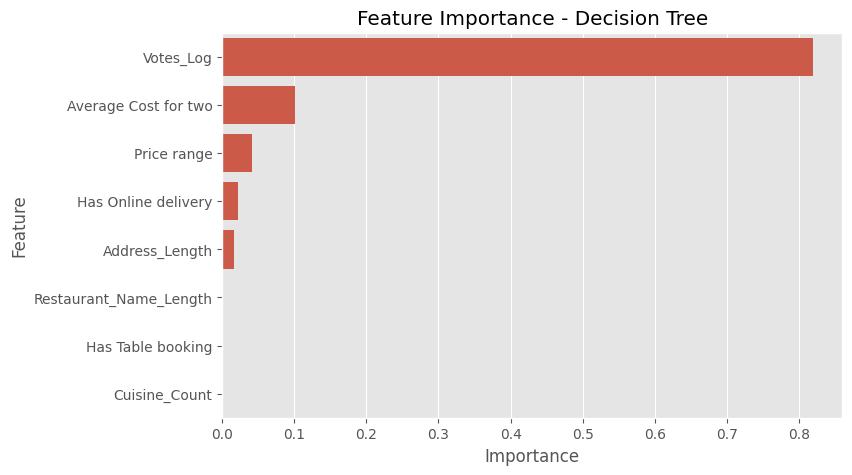

In [98]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Decision Tree")
plt.show()

Decision Tree Regression achieved an R² score of 0.522, slightly outperforming Linear Regression. Feature importance analysis revealed that the number of customer votes was the most influential predictor of restaurant ratings, contributing approximately 82% of the model's predictive power. Average cost for two and price range were also important factors, while table booking and cuisine count had minimal impact on predictions.

In [99]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [100]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = mean_squared_error(
    y_test,
    y_pred_rf
) ** 0.5

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

MAE : 0.2804810544677021
RMSE: 0.3757199721211509
R²  : 0.5435680726860643


In [101]:
results.loc[len(results)] = [
    "Random Forest",
    mae_rf,
    rmse_rf,
    r2_rf
]

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.289466,0.393125,0.500302
1,Decision Tree,0.287702,0.384324,0.522423
2,Random Forest,0.280481,0.375720,0.543568


Three machine learning models were developed to predict restaurant aggregate ratings: Linear Regression, Decision Tree Regression, and Random Forest Regression. Among the models evaluated, Random Forest achieved the best performance with an MAE of 0.280, RMSE of 0.376, and an R² score of 0.544. The results indicate that customer engagement (votes), restaurant pricing, and delivery-related features contribute significantly to rating prediction. Although the model explains over 54% of the variation in ratings, additional factors such as food quality, service, and ambience, which are not available in the dataset, likely influence restaurant ratings.

In [102]:
cuisine_rating = (
    df.assign(Cuisine=df["Cuisines"].str.split(","))
      .explode("Cuisine")
)

cuisine_rating["Cuisine"] = (
    cuisine_rating["Cuisine"]
    .str.strip()
)

In [103]:
avg_rating_by_cuisine = (
    cuisine_rating
    .groupby("Cuisine")
    ["Aggregate rating"]
    .mean()
    .sort_values(ascending=False)
)

avg_rating_by_cuisine.head(15)

,Aggregate rating
Cuisine,
Sunda,4.900000
B�_rek,4.700000
Taiwanese,4.650000
Ramen,4.500000
Dim Sum,4.466667
Hawaiian,4.412500
D�_ner,4.400000
Bubble Tea,4.400000
Curry,4.400000


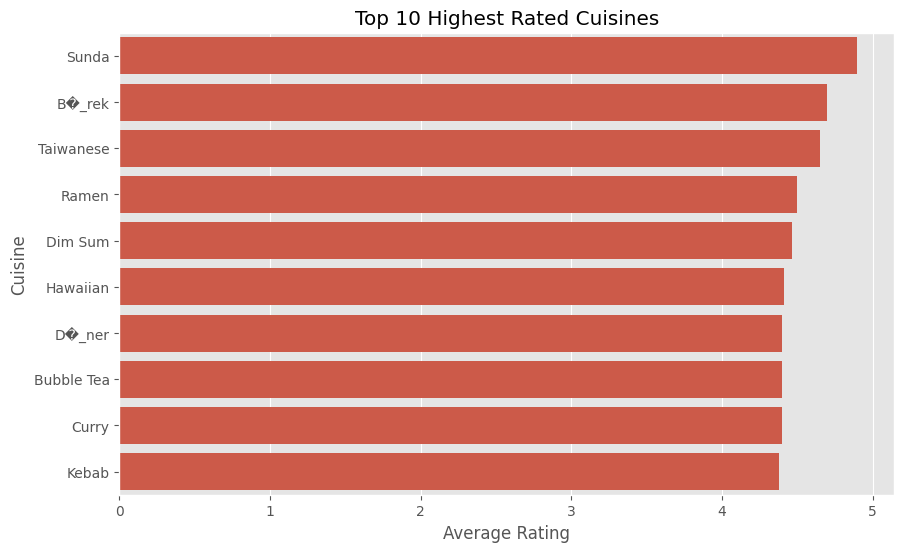

In [104]:
top_rated_cuisines = avg_rating_by_cuisine.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_rated_cuisines.values,
    y=top_rated_cuisines.index
)

plt.title("Top 10 Highest Rated Cuisines")
plt.xlabel("Average Rating")
plt.ylabel("Cuisine")

plt.show()

In [105]:
popular_cuisines = (
    cuisine_rating
    .groupby("Cuisine")
    ["Votes"]
    .sum()
    .sort_values(ascending=False)
)

popular_cuisines.head(15)

,Votes
Cuisine,
North Indian,595981
Chinese,364351
Italian,329265
Continental,288255
Fast Food,184058
American,183117
Cafe,177568
Mughlai,151946
Desserts,105889


In [108]:
cuisine_stats = (
    cuisine_rating
    .groupby("Cuisine")
    .agg({
        "Aggregate rating": "mean",
        "Restaurant ID": "count",
        "Votes": "sum"
    })
)

cuisine_stats.columns = [
    "Average_Rating",
    "Restaurant_Count",
    "Total_Votes"
]

cuisine_stats = cuisine_stats[
    cuisine_stats["Restaurant_Count"] >= 20
]

cuisine_stats.sort_values(
    "Average_Rating",
    ascending=False
).head(15)

,Average_Rating,Restaurant_Count,Total_Votes
Cuisine,,,
International,4.247619,21,8122
Southern,4.129167,24,13939
Vegetarian,4.073913,23,10714
Sandwich,4.066038,53,23500
Grill,4.057143,21,4301
Steak,3.985484,62,25677
Sushi,3.973333,75,20582
Goan,3.970000,20,11488
Breakfast,3.965854,41,16097


<Axes: xlabel='Aggregate rating', ylabel='Count'>

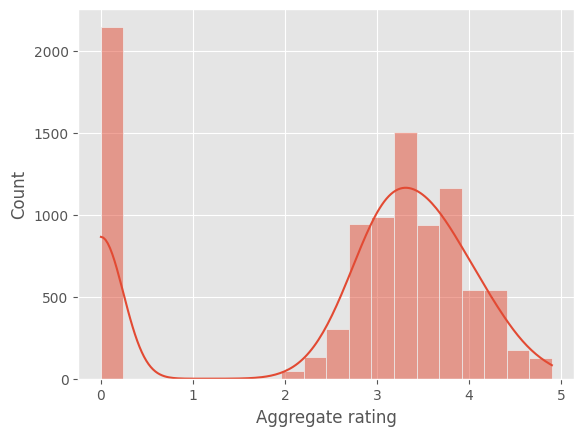

In [109]:
sns.histplot(df["Aggregate rating"], bins=20, kde=True)

<Axes: xlabel='Price range', ylabel='Aggregate rating'>

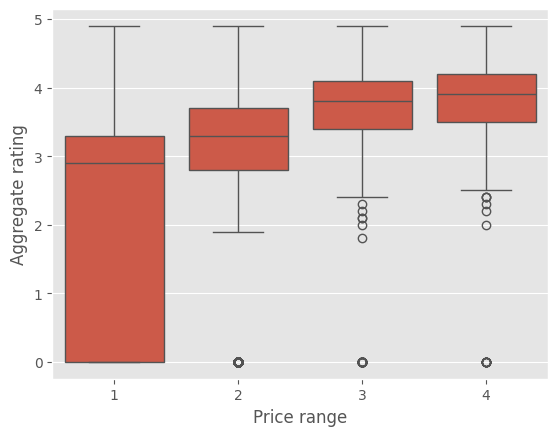

In [110]:
sns.boxplot(
    data=df,
    x="Price range",
    y="Aggregate rating"
)

<Axes: xlabel='Votes', ylabel='Aggregate rating'>

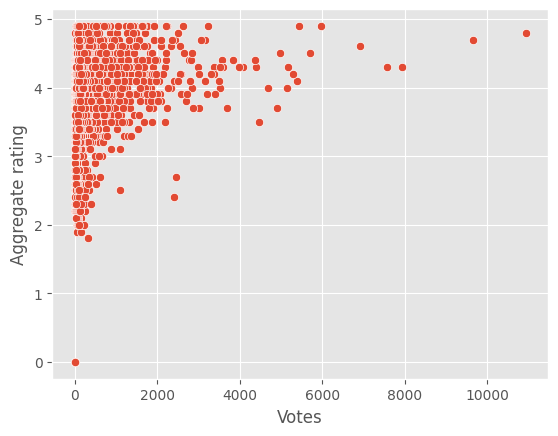

In [111]:
sns.scatterplot(
    data=df,
    x="Votes",
    y="Aggregate rating"
)

<Axes: ylabel='City'>

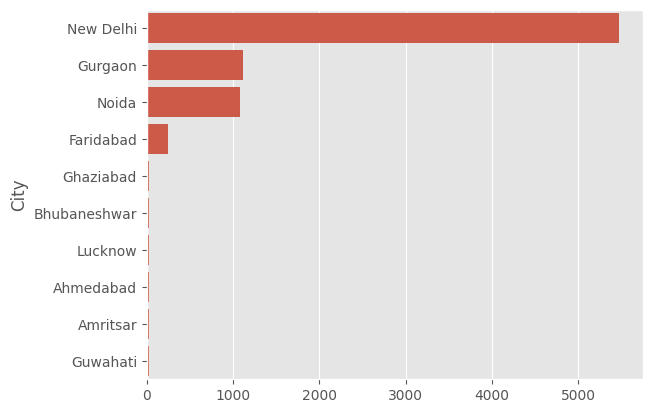

In [112]:
sns.barplot(
    x=top_cities.values,
    y=top_cities.index
)

<Axes: ylabel='Cuisine'>

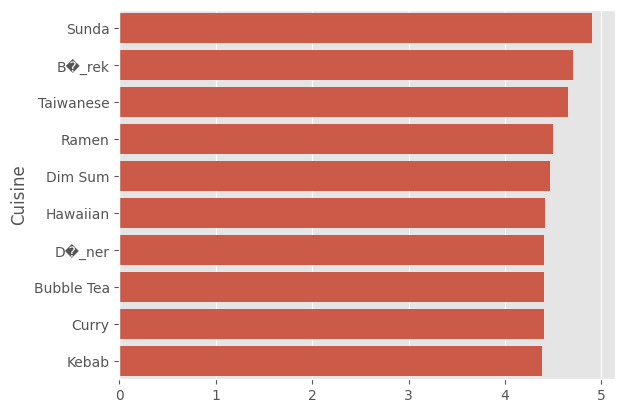

In [113]:
sns.barplot(
    x=top_rated_cuisines.values,
    y=top_rated_cuisines.index
)

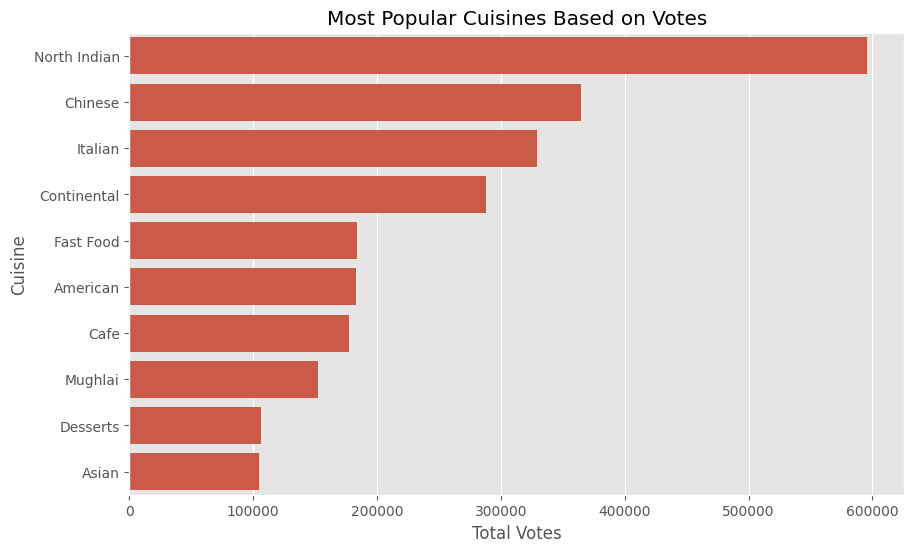

In [106]:
top_popular = popular_cuisines.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_popular.values,
    y=top_popular.index
)

plt.title("Most Popular Cuisines Based on Votes")
plt.xlabel("Total Votes")
plt.ylabel("Cuisine")

plt.show()

In [107]:
cuisine_stats = (
    cuisine_rating
    .groupby("Cuisine")
    .agg({
        "Aggregate rating":"mean",
        "Restaurant ID":"count"
    })
)

cuisine_stats.columns = [
    "Average_Rating",
    "Restaurant_Count"
]

cuisine_stats = cuisine_stats[
    cuisine_stats["Restaurant_Count"] >= 20
]

cuisine_stats.sort_values(
    "Average_Rating",
    ascending=False
).head(15)

,Average_Rating,Restaurant_Count
Cuisine,,
International,4.247619,21
Southern,4.129167,24
Vegetarian,4.073913,23
Sandwich,4.066038,53
Grill,4.057143,21
Steak,3.985484,62
Sushi,3.973333,75
Goan,3.970000,20
Breakfast,3.965854,41


## Key Insights

1. India accounts for approximately 90% of restaurants in the dataset.

2. New Delhi has the highest concentration of restaurants.

3. North Indian cuisine is the most frequently occurring cuisine.

4. Restaurants offering table booking have significantly higher average ratings.

5. Higher price ranges generally receive higher ratings.

6. Customer votes are the strongest predictor of restaurant ratings.

7. Random Forest achieved the best predictive performance with an R² score of 54.36%.

## Conclusion

This project analyzed restaurant data to identify factors influencing customer ratings.

Through exploratory data analysis, feature engineering, and predictive modeling, it was found that customer engagement (votes), pricing, and restaurant services significantly impact ratings.

Among the evaluated models, Random Forest Regressor achieved the best performance with the highest R² score and lowest prediction error, making it the most suitable model for restaurant rating prediction.

In [114]:
df.to_csv(
    "cleaned_restaurant_dataset.csv",
    index=False
)

In [115]:
df_model.to_csv(
    "restaurant_model_dataset.csv",
    index=False
)

In [116]:
df_model = df[df["Aggregate rating"] > 0].copy()

In [117]:
import joblib

joblib.dump(
    rf,
    "restaurant_rating_model.pkl"
)

['restaurant_rating_model.pkl']